# Exercises

## 1. What is the approximate depth of a Decision Tree trained (without restrictions) on a training set with 1 million instances?

Depth grows roughly proportional to log₂(N), where N is the number of training examples.
log2​(1,000,000) = 20

## 2. Is a node’s Gini impurity generally lower or greater than its parent’s? Is it generally lower/greater, or always lower/greater?

A node’s Gini impurity is generally lower than its parent’s, but not always (rare cases).

## 3. If a Decision Tree is overfitting the training set, is it a good idea to try decreasing max_depth?

If a Decision Tree is overfitting, it means it has grown too deep and is memorizing noise from the training set. By decreasing max_depth, you limit how many splits the tree can make, which simplifies the model and usually improves its ability to generalize to new data.

## 4. If a Decision Tree is underfitting the training set, is it a good idea to try scaling the input features?

Scaling the input features will not help a Decision Tree when it is underfitting. 
Decision Trees split the data based on feature thresholds, so they are invariant to feature scaling.
Better options include increasing max_depth, increasing max_leaf_nodes, or reducing min_samples_split, so the tree can grow more complex and capture more patterns.

## 5. If it takes one hour to train a Decision Tree on a training set containing 1 million instances, roughly how much time will it take to train another Decision Tree on a training set containing 10 million instances?

Roughly 11 to 12 hours.

## 6. If your training set contains 100,000 instances, will setting presort=True speed up training?

Setting presort=True only helps when the dataset is small or the tree is very shallow, because it avoids repeatedly sorting values at each split.

## 7. Train and fine-tune a Decision Tree for the moons dataset.

## a. Generate a moons dataset using make_moons(n_samples=10000, noise=0.4).

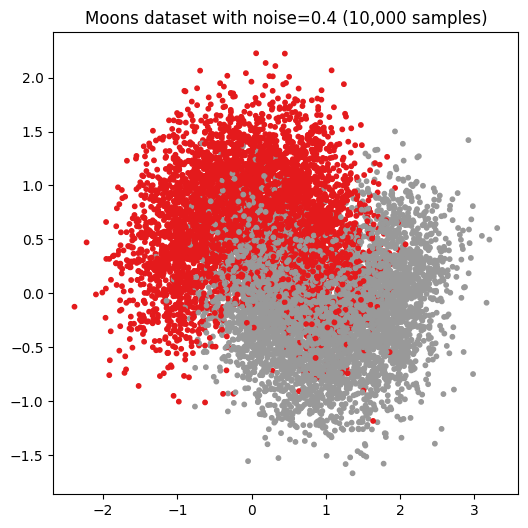

In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate dataset
X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)

# Quick visualization
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, s=10)
plt.title("Moons dataset with noise=0.4 (10,000 samples)")
plt.show()

## b. Split it into a training set and a test set using train_test_split().

In [2]:
from sklearn.model_selection import train_test_split

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (8000, 2)
Test set size: (2000, 2)


## c. Use grid search with cross-validation (with the help of the GridSearchCV class) to find good hyperparameter values for a DecisionTreeClassifier. Hint: try various values for max_leaf_nodes.

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the base model
tree_clf = DecisionTreeClassifier(random_state=42)

# Define parameter grid (focus on max_leaf_nodes)
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_leaf_nodes": [5, 10, 20, 50, 100, 200, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit on training set
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score: 0.858125


## d. Train it on the full training set using these hyperparameters, and measure your model’s performance on the test set. You should get roughly 85% to 87% accuracy.

In [4]:
from sklearn.metrics import accuracy_score

# Retrieve best hyperparameters from grid search
best_params = grid_search.best_params_

# Train final model on full training set
final_tree_clf = DecisionTreeClassifier(
    **best_params, random_state=42
)
final_tree_clf.fit(X_train, y_train)

# Predict on test set
y_pred = final_tree_clf.predict(X_test)

# Evaluate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy:", test_accuracy)

Test set accuracy: 0.853


## 8. Grow a forest.

## a. Continuing the previous exercise, generate 1,000 subsets of the training set, each containing 100 instances selected randomly. Hint: you can use ScikitLearn’s ShuffleSplit class for this.

In [5]:
from sklearn.model_selection import ShuffleSplit

# ShuffleSplit configuration: 1000 splits, each with 100 instances
shuffle_split = ShuffleSplit(
    n_splits=1000,
    train_size=100,
    test_size=None,
    random_state=42
)

# Generate subsets (just an example with the first 3)
subsets = []
for train_idx, _ in shuffle_split.split(X_train):
    X_subset = X_train[train_idx]
    y_subset = y_train[train_idx]
    subsets.append((X_subset, y_subset))

# Show how many subsets were created
print("Number of subsets generated:", len(subsets))
print("Shape of one subset:", subsets[0][0].shape, subsets[0][1].shape)


Number of subsets generated: 1000
Shape of one subset: (100, 2) (100,)


## b. Train one Decision Tree on each subset, using the best hyperparameter values found above. Evaluate these 1,000 Decision Trees on the test set. Since they were trained on smaller sets, these Decision Trees will likely perform worse than the first Decision Tree, achieving only about 80% accuracy.

In [6]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Use the subsets we created in step (a)
# 'subsets' is a list of (X_subset, y_subset)
# 'best_params' comes from the previous GridSearchCV

accuracies = []

for i, (X_sub, y_sub) in enumerate(subsets):
    clf = DecisionTreeClassifier(**best_params, random_state=42)  # same hyperparams
    clf.fit(X_sub, y_sub)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

accuracies = np.array(accuracies)
print(f"Number of models: {len(accuracies)}")
print(f"Mean accuracy: {accuracies.mean():.3f}")
print(f"Std dev: {accuracies.std():.3f}")
print(f"Min / Max: {accuracies.min():.3f} / {accuracies.max():.3f}")


Number of models: 1000
Mean accuracy: 0.798
Std dev: 0.026
Min / Max: 0.672 / 0.859


## c. Now comes the magic. For each test set instance, generate the predictions of the 1,000 Decision Trees, and keep only the most frequent prediction (you can use SciPy’s mode() function for this). This gives you majority-vote predictions over the test set.

In [7]:
import numpy as np
from scipy.stats import mode

# Collect predictions from all 1,000 trees
all_preds = []

for i, (X_sub, y_sub) in enumerate(subsets):
    clf = DecisionTreeClassifier(**best_params, random_state=42)
    clf.fit(X_sub, y_sub)
    preds = clf.predict(X_test)
    all_preds.append(preds)

# Convert list to array: shape = (1000, n_test_samples)
all_preds = np.array(all_preds)

# Majority vote across trees (axis=0 = trees, axis=1 = samples)
y_majority_vote, _ = mode(all_preds, axis=0, keepdims=False)

print("Shape of majority-vote predictions:", y_majority_vote.shape)

Shape of majority-vote predictions: (2000,)


## d. Evaluate these predictions on the test set: you should obtain a slightly higher accuracy than your first model (about 0.5 to 1.5% higher). Congratulations, you have trained a Random Forest classifier

In [8]:
from sklearn.metrics import accuracy_score

# Evaluate majority-vote predictions
final_acc = accuracy_score(y_test, y_majority_vote)
print(f"Random Forest (majority vote) accuracy: {final_acc:.3f}")

Random Forest (majority vote) accuracy: 0.864
